# Day 2: Dimensionality Reduction with PCA

<a target="_blank" href="https://colab.research.google.com/github/LuWidme/uk259/blob/main/demos/05_Dimensionality_Reduction.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

**Duration:** 2-3 hours  
**Prerequisites:** NumPy basics, linear algebra fundamentals, data visualization  

**Learning Objectives:**
- Understand what dimensionality reduction is and why it's important
- Learn how Principal Component Analysis (PCA) works mathematically
- Implement PCA from scratch using eigenvalue decomposition
- Apply sklearn's PCA to real datasets
- Visualize high-dimensional data in 2D/3D
- Understand when to use PCA vs other methods (t-SNE, UMAP)

**Datasets Used:** Iris dataset (4D), synthetic data

---

## What is Dimensionality Reduction?

**Simple explanation:** Dimensionality reduction is the process of reducing the number of features (dimensions) in your data while keeping as much important information as possible.

**Real-world analogy:** Imagine you're taking a photo of a 3D sculpture. The photo is 2D, but it still captures most of the important visual information about the sculpture. You've reduced the dimensions from 3D to 2D while preserving the key details.

### Why is Dimensionality Reduction Important?

**The Curse of Dimensionality:**
- As the number of features increases, the volume of the space increases exponentially
- Data becomes sparse (points are far apart)
- Machine learning algorithms struggle and require exponentially more data
- Visualization becomes impossible (humans can only see 3D)

**Benefits of dimensionality reduction:**
1. **Visualization**: Plot high-dimensional data in 2D/3D
2. **Speed**: Fewer features → faster training
3. **Storage**: Less data to store and process
4. **Noise reduction**: Remove irrelevant or redundant features
5. **Avoid overfitting**: Simpler models generalize better

**Common applications:**
- **Image compression**: Reduce pixel dimensions while keeping visual quality
- **Feature engineering**: Create meaningful features from high-dimensional data
- **Data visualization**: Understand patterns in complex datasets
- **Preprocessing**: Prepare data before machine learning
- **Face recognition**: Eigenfaces method uses PCA

### What is Principal Component Analysis (PCA)?

**PCA** finds new axes (principal components) that capture the maximum variance in your data.

**Key concepts:**
- **Principal Component 1 (PC1)**: The direction where data varies the most
- **Principal Component 2 (PC2)**: The direction with second-most variance (perpendicular to PC1)
- **And so on**: Each new PC is perpendicular to previous ones

**How it works (intuitive):**
1. Center the data (subtract mean)
2. Find the direction of maximum variance → PC1
3. Find the next perpendicular direction of maximum variance → PC2
4. Continue for all dimensions
5. Keep only the top k components (dimensionality reduction!)

**Visual intuition:**
```
Original 2D data:        After PCA rotation:     Reduced to 1D:
  •     •                      •••••               •••••
   •   •                                           (PC1 axis only)
    • •         →         PC1 ↗    ↖ PC2
   •   •
  •     •
```

---

## Setup

Let's import the necessary libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D

# Set style
sns.set_style('whitegrid')
%matplotlib inline

# Set random seed for reproducibility
np.random.seed(42)

---

## Part 1: Understanding the Problem - Visualizing High-Dimensional Data

Let's start with the classic **Iris dataset**, which has 4 features (dimensions):
1. Sepal length
2. Sepal width
3. Petal length
4. Petal width

**Challenge**: How do we visualize 4D data?

In [2]:
# Load the Iris dataset
iris = datasets.load_iris(as_frame=True)
X = iris.data  # Features (4D)
y = iris.target  # Target labels (species)
target_names = iris.target_names

print("Dataset shape:", X.shape)
print("Number of samples:", len(X))
print("Number of features:", X.shape[1])
print("\nFeature names:", iris.feature_names)
print("\nTarget names:", target_names)
print("\nFirst 5 rows:")
print(X.head())

Dataset shape: (150, 4)
Number of samples: 150
Number of features: 4

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target names: ['setosa' 'versicolor' 'virginica']

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


### Approach 1: Pairplot (All 2D Projections)

One way to visualize 4D data is to look at all possible 2D scatter plots:

<Figure size 1200x1000 with 0 Axes>

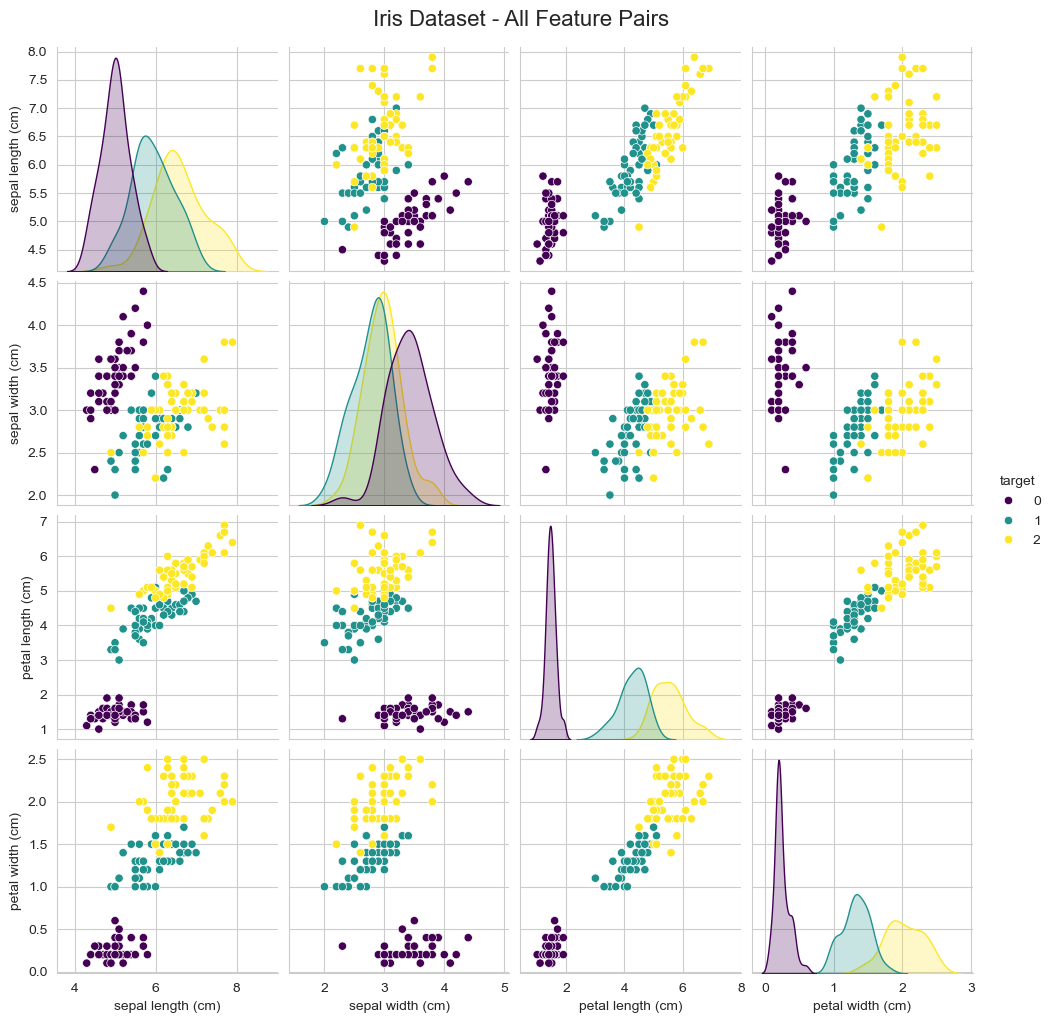


Observation: We can see patterns, but it's overwhelming!
With 4 features, we need 6 different 2D plots.
Imagine having 50 features... we'd need 1,225 plots!


In [3]:
# Create a pairplot
plt.figure(figsize=(12, 10))
sns.pairplot(iris.frame, hue='target', palette='viridis', height=2.5)
plt.suptitle('Iris Dataset - All Feature Pairs', y=1.02, fontsize=16)
plt.show()

print("\nObservation: We can see patterns, but it's overwhelming!")
print("With 4 features, we need 6 different 2D plots.")
print("Imagine having 50 features... we'd need 1,225 plots!")

### Approach 2: 3D Plot with 4th Dimension as Color

We can use 3 axes for the first 3 features and color for the 4th:

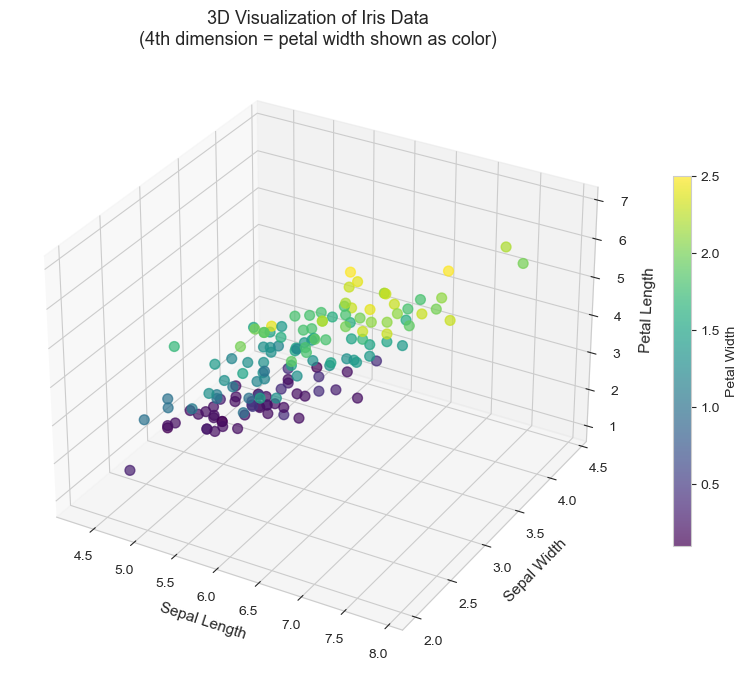


This works for 4D, but what about 10D? 50D? 1000D?
We need a better solution: Dimensionality Reduction!


In [4]:
# Create 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Use first 3 features for axes, 4th for color
scatter = ax.scatter(
    X.iloc[:, 0],  # sepal length
    X.iloc[:, 1],  # sepal width
    X.iloc[:, 2],  # petal length
    c=X.iloc[:, 3],  # petal width (as color)
    cmap='viridis',
    s=50,
    alpha=0.7
)

ax.set_xlabel('Sepal Length', fontsize=11)
ax.set_ylabel('Sepal Width', fontsize=11)
ax.set_zlabel('Petal Length', fontsize=11)
ax.set_title('3D Visualization of Iris Data\n(4th dimension = petal width shown as color)', 
             fontsize=13)
plt.colorbar(scatter, label='Petal Width', ax=ax, shrink=0.6)
plt.show()

print("\nThis works for 4D, but what about 10D? 50D? 1000D?")
print("We need a better solution: Dimensionality Reduction!")

---

## Part 2: Implementing PCA from Scratch

To truly understand PCA, let's implement it step-by-step.

### Mathematical Foundation

PCA uses linear algebra to find principal components:

1. **Center the data**: $X_{centered} = X - \bar{X}$
2. **Compute covariance matrix**: $C = \frac{1}{n-1} X_{centered}^T X_{centered}$
3. **Find eigenvalues and eigenvectors** of $C$
4. **Sort eigenvectors** by eigenvalue (descending)
5. **Project data** onto top k eigenvectors

**Key insight**: Eigenvectors are the principal components, eigenvalues tell us how much variance each captures.

Let's start with a simple 2D example:

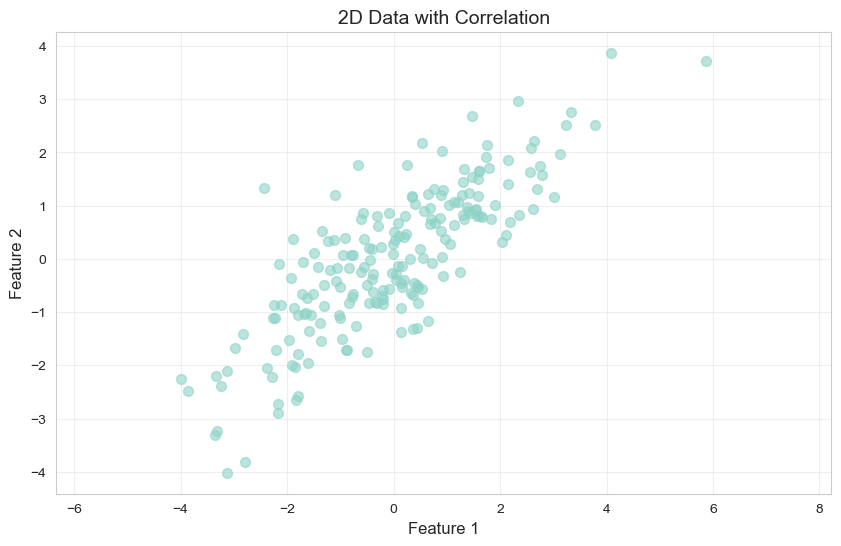

Notice: The data is not aligned with the axes.
PCA will find new axes (principal components) that better align with the data spread.


In [5]:
# Generate 2D data with correlation
np.random.seed(42)
mean = [0, 0]
cov = [[3, 2],   # Covariance matrix: features are correlated
       [2, 2]]
X_2d = np.random.multivariate_normal(mean, cov, 200)

# Visualize original data
plt.figure(figsize=(10, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.6, s=50)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('2D Data with Correlation', fontsize=14)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

print("Notice: The data is not aligned with the axes.")
print("PCA will find new axes (principal components) that better align with the data spread.")

### Task 1: Center the Data

**Goal**: Subtract the mean from each feature to center the data around the origin.

**Why?** PCA needs centered data because we're looking for directions of variance relative to the mean.

**Instructions:**
1. Calculate the mean of each feature
2. Subtract the mean from the data
3. Verify that the new mean is approximately zero

**Hint:** Use `np.mean()` with the correct axis.

In [7]:
def center_data(X):
    """
    Center the data by subtracting the mean of each feature.
    
    Parameters:
    -----------
    X : ndarray of shape (n_samples, n_features)
        The input data
    
    Returns:
    --------
    X_centered : ndarray of shape (n_samples, n_features)
        The centered data
    mean : ndarray of shape (n_features,)
        The mean of each feature
    """
    # TODO: Calculate mean of each feature (column)
    mean = None  # Use np.mean() with axis=0
    
    # TODO: Subtract mean from data
    X_centered = None  # X - mean
    
    return X_centered, mean

# Test your function
X_centered, data_mean = center_data(X_2d)

print("Original data mean:", data_mean)
print("Centered data mean:", np.mean(X_centered, axis=0))
print("(Should be close to [0, 0])")

# Visualize centered data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.6, s=50)
axes[0].scatter(data_mean[0], data_mean[1], c='red', s=200, marker='X', 
                edgecolors='black', linewidths=2, label='Mean')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].set_title('Original Data')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.6, s=50)
axes[1].scatter(0, 0, c='red', s=200, marker='X', 
                edgecolors='black', linewidths=2, label='Mean (origin)')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].set_title('Centered Data')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Original data mean: None


AxisError: axis 0 is out of bounds for array of dimension 0

---

### Task 2: Compute the Covariance Matrix

**Goal**: Calculate the covariance matrix, which describes how features vary together.

**Math**: $C = \frac{1}{n-1} X^T X$ (for centered data)

**What it means**:
- Diagonal elements: variance of each feature
- Off-diagonal elements: covariance between features

**Instructions:**
1. Use matrix multiplication to compute $X^T X$
2. Divide by (n-1) where n is the number of samples
3. Examine the covariance matrix

**Hint:** Use `np.dot()` or `@` for matrix multiplication, `X.T` for transpose.

In [ ]:
def compute_covariance_matrix(X_centered):
    """
    Compute the covariance matrix of centered data.
    
    Parameters:
    -----------
    X_centered : ndarray of shape (n_samples, n_features)
        The centered data
    
    Returns:
    --------
    cov_matrix : ndarray of shape (n_features, n_features)
        The covariance matrix
    """
    n_samples = X_centered.shape[0]
    
    # TODO: Compute covariance matrix
    # Formula: (1 / (n-1)) * X^T @ X
    cov_matrix = None
    
    return cov_matrix

# Test your function
cov_matrix = compute_covariance_matrix(X_centered)

print("Covariance Matrix:")
print(cov_matrix)
print("\nInterpretation:")
print(f"  Variance of Feature 1: {cov_matrix[0, 0]:.3f}")
print(f"  Variance of Feature 2: {cov_matrix[1, 1]:.3f}")
print(f"  Covariance between features: {cov_matrix[0, 1]:.3f}")
print(f"  (Positive covariance means they increase together)")

# Verify with NumPy's built-in function
np_cov = np.cov(X_centered.T)
print("\nNumPy's covariance matrix (for verification):")
print(np_cov)
print(f"\nMatrices match: {np.allclose(cov_matrix, np_cov)}")

---

### Task 3: Compute Eigenvalues and Eigenvectors

**Goal**: Find the eigenvalues and eigenvectors of the covariance matrix.

**What are they?**
- **Eigenvectors**: The principal component directions
- **Eigenvalues**: The amount of variance captured by each eigenvector

**Math**: For covariance matrix $C$ and eigenvector $v$:
$$C v = \lambda v$$

where $\lambda$ is the eigenvalue.

**Instructions:**
1. Use `np.linalg.eig()` to compute eigenvalues and eigenvectors
2. Sort them by eigenvalue (descending order)
3. The first eigenvector is PC1, the second is PC2, etc.

**Hint:** `np.argsort()` returns indices that would sort an array.

In [ ]:
def compute_eigen(cov_matrix):
    """
    Compute eigenvalues and eigenvectors, sorted by eigenvalue.
    
    Parameters:
    -----------
    cov_matrix : ndarray of shape (n_features, n_features)
        The covariance matrix
    
    Returns:
    --------
    eigenvalues : ndarray of shape (n_features,)
        Eigenvalues in descending order
    eigenvectors : ndarray of shape (n_features, n_features)
        Eigenvectors as columns, sorted by eigenvalue
    """
    # TODO: Compute eigenvalues and eigenvectors
    eigenvalues, eigenvectors = None  # Use np.linalg.eig()
    
    # TODO: Sort by eigenvalue (descending)
    idx = None  # Use np.argsort()[::-1] to get descending order
    eigenvalues = None  # eigenvalues[idx]
    eigenvectors = None  # eigenvectors[:, idx]
    
    return eigenvalues, eigenvectors

# Test your function
eigenvalues, eigenvectors = compute_eigen(cov_matrix)

print("Eigenvalues (variance captured by each PC):")
for i, val in enumerate(eigenvalues):
    print(f"  PC{i+1}: {val:.3f}")

print("\nEigenvectors (principal component directions):")
for i in range(len(eigenvalues)):
    print(f"  PC{i+1}: {eigenvectors[:, i]}")

print("\nVariance explained ratio:")
total_variance = np.sum(eigenvalues)
explained_variance_ratio = eigenvalues / total_variance
for i, ratio in enumerate(explained_variance_ratio):
    print(f"  PC{i+1}: {ratio:.1%}")

print(f"\nPC1 captures {explained_variance_ratio[0]:.1%} of total variance!")

### Visualize Principal Components

Let's plot the data with the principal component vectors:

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.6, s=50, label='Data points')

# Draw principal component vectors
origin = [0, 0]
colors = ['red', 'green']
labels = ['PC1 (most variance)', 'PC2 (second-most variance)']

for i in range(2):
    # Scale eigenvector by sqrt of eigenvalue for visualization
    vec = eigenvectors[:, i] * np.sqrt(eigenvalues[i]) * 2
    plt.arrow(origin[0], origin[1], vec[0], vec[1],
              head_width=0.2, head_length=0.3, fc=colors[i], ec=colors[i],
              linewidth=3, label=labels[i], alpha=0.8)
    
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('Data with Principal Components', fontsize=14)
plt.legend(fontsize=11)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

print("\nKey observation:")
print("- PC1 (red) points in the direction of maximum spread")
print("- PC2 (green) is perpendicular to PC1")
print("- These are the new 'axes' that best describe the data")

---

### Task 4: Project Data onto Principal Components

**Goal**: Transform the data into the new coordinate system defined by principal components.

**Math**: $X_{pca} = X_{centered} \cdot V_k$

where $V_k$ contains the first k eigenvectors as columns.

**Instructions:**
1. Select the first k eigenvectors (columns)
2. Project the centered data onto these eigenvectors using matrix multiplication
3. The result is your data in the new PCA space

**Hint:** Use `@` or `np.dot()` for matrix multiplication.

In [ ]:
def project_data(X_centered, eigenvectors, n_components):
    """
    Project data onto the first n_components principal components.
    
    Parameters:
    -----------
    X_centered : ndarray of shape (n_samples, n_features)
        The centered data
    eigenvectors : ndarray of shape (n_features, n_features)
        The eigenvectors (principal component directions)
    n_components : int
        Number of components to keep
    
    Returns:
    --------
    X_pca : ndarray of shape (n_samples, n_components)
        Data projected onto principal components
    """
    # TODO: Select first n_components eigenvectors
    components = None  # eigenvectors[:, :n_components]
    
    # TODO: Project data
    X_pca = None  # X_centered @ components
    
    return X_pca

# Test your function - reduce from 2D to 1D
X_pca_1d = project_data(X_centered, eigenvectors, n_components=1)

print("Original shape:", X_centered.shape)
print("Reduced shape:", X_pca_1d.shape)
print("\nFirst 5 values on PC1:")
print(X_pca_1d[:5])

# Visualize the dimensionality reduction
plt.figure(figsize=(10, 6))
sns.histplot(X_pca_1d.flatten(), bins=30, kde=True)
plt.xlabel('PC1 Value', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Data on First Principal Component', fontsize=14)
plt.show()

print("\nWe've reduced 2D data to 1D while keeping the most important variance!")

### Visualize Dimensionality Reduction Effect

Let's see what information is lost when we reduce dimensions:

In [ ]:
# Project back to original space
def reconstruct_data(X_pca, eigenvectors, mean):
    """
    Reconstruct data from PCA space back to original space.
    """
    n_components = X_pca.shape[1]
    components = eigenvectors[:, :n_components]
    X_reconstructed = X_pca @ components.T + mean
    return X_reconstructed

X_reconstructed = reconstruct_data(X_pca_1d, eigenvectors, data_mean)

# Visualize original vs reconstructed
plt.figure(figsize=(12, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.3, s=50, color='red', label='Original data')
plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], alpha=0.6, s=30, 
            color='blue', label='Reconstructed (from 1D)')
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('Original Data vs Reconstructed from 1 Principal Component', fontsize=14)
plt.legend(fontsize=11)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

print("Blue points lie exactly on the PC1 axis!")
print("We've compressed 2D→1D, losing some information but keeping the main pattern.")

---

### Task 5: Complete PCA Implementation

**Goal**: Combine all steps into a complete PCA function.

**Instructions:**
Put together everything from Tasks 1-4 into one function.

In [ ]:
def my_pca(X, n_components):
    """
    Complete PCA implementation from scratch.
    
    Parameters:
    -----------
    X : ndarray of shape (n_samples, n_features)
        The input data
    n_components : int
        Number of principal components to keep
    
    Returns:
    --------
    X_pca : ndarray of shape (n_samples, n_components)
        Transformed data
    explained_variance_ratio : ndarray of shape (n_components,)
        Percentage of variance explained by each component
    components : ndarray of shape (n_components, n_features)
        Principal component vectors
    """
    # TODO: Step 1 - Center the data
    X_centered, mean = None, None
    
    # TODO: Step 2 - Compute covariance matrix
    cov_matrix = None
    
    # TODO: Step 3 - Compute eigenvalues and eigenvectors
    eigenvalues, eigenvectors = None, None
    
    # TODO: Step 4 - Project data
    X_pca = None
    
    # Calculate explained variance ratio
    explained_variance_ratio = eigenvalues[:n_components] / np.sum(eigenvalues)
    
    components = eigenvectors[:, :n_components].T
    
    return X_pca, explained_variance_ratio, components

# Test on 2D data
X_transformed, var_ratio, components = my_pca(X_2d, n_components=2)

print("PCA Results:")
print(f"Original shape: {X_2d.shape}")
print(f"Transformed shape: {X_transformed.shape}")
print(f"\nVariance explained:")
for i, ratio in enumerate(var_ratio):
    print(f"  PC{i+1}: {ratio:.1%}")
print(f"  Total: {np.sum(var_ratio):.1%}")

---

## Part 3: Using Scikit-learn's PCA

Now that we understand how PCA works, let's use sklearn's optimized implementation.

### Apply PCA to Iris Dataset

Let's reduce the 4D Iris data to 2D for visualization:

In [ ]:
# Standardize the features (important for PCA!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X.shape)
print("Reduced shape:", X_pca.shape)
print("\nVariance explained by each component:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {ratio:.1%}")
print(f"\nTotal variance explained: {np.sum(pca.explained_variance_ratio_):.1%}")
print("\nWe've reduced from 4D to 2D while keeping {:.1%} of the information!".format(
    np.sum(pca.explained_variance_ratio_)))

### Visualize the Result

Now we can plot the 4D Iris data in 2D:

In [ ]:
# Create a beautiful visualization
plt.figure(figsize=(12, 8))
colors = ['navy', 'turquoise', 'darkorange']

for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(
        X_pca[y == i, 0],
        X_pca[y == i, 1],
        color=color,
        alpha=0.8,
        s=60,
        label=target_name,
        edgecolors='black',
        linewidth=0.5
    )

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.title('Iris Dataset - PCA Projection (4D → 2D)', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11, shadow=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nAmazing! We can now see all 3 species clearly separated in 2D.")
print("The 4 original features (sepal/petal length/width) have been combined")
print("into 2 principal components that capture the most important patterns.")

---

## Part 4: Determining Optimal Number of Components

**Question**: How many principal components should we keep?

### Scree Plot

A **scree plot** shows the variance explained by each component. Look for an "elbow" where adding more components doesn't help much.

In [ ]:
# Fit PCA with all components
pca_full = PCA(n_components=4)
pca_full.fit(X_scaled)

# Create scree plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Variance explained by each component
axes[0].bar(range(1, 5), pca_full.explained_variance_ratio_, alpha=0.7, color='steelblue')
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Variance Explained', fontsize=12)
axes[0].set_title('Variance Explained by Each PC', fontsize=13)
axes[0].set_xticks(range(1, 5))
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Cumulative variance explained
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, 5), cumulative_variance, 'bo-', linewidth=2, markersize=8)
axes[1].axhline(y=0.95, color='red', linestyle='--', alpha=0.7, label='95% threshold')
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Variance Explained', fontsize=12)
axes[1].set_title('Cumulative Variance Explained', fontsize=13)
axes[1].set_xticks(range(1, 5))
axes[1].set_ylim([0, 1.05])
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Add value labels
for i, val in enumerate(cumulative_variance):
    axes[1].text(i+1, val+0.02, f'{val:.1%}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\nVariance explained:")
for i, (individual, cumulative) in enumerate(zip(pca_full.explained_variance_ratio_, 
                                                   cumulative_variance)):
    print(f"  PC{i+1}: {individual:.1%} (cumulative: {cumulative:.1%})")

print("\nRule of thumb: Keep enough components to explain 95% of variance.")
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"For Iris dataset: {n_components_95} components explain ≥95% variance")

---

## Part 5: Understanding Principal Components

### What do the principal components mean?

Each PC is a weighted combination of the original features. Let's examine the weights:

In [ ]:
# Create a DataFrame showing component loadings
components_df = pd.DataFrame(
    pca_full.components_,
    columns=iris.feature_names,
    index=[f'PC{i+1}' for i in range(4)]
)

print("Principal Component Loadings:")
print("(How much each feature contributes to each PC)\n")
print(components_df)

# Visualize as heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(components_df, annot=True, cmap='RdBu_r', center=0, 
            linewidths=1, linecolor='black', fmt='.2f', cbar_kws={'label': 'Loading'})
plt.title('PCA Component Loadings Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Principal Component', fontsize=12)
plt.xlabel('Original Feature', fontsize=12)
plt.tight_layout()
plt.show()

print("\nInterpretation of PC1:")
pc1_loadings = components_df.loc['PC1']
strongest_feature = pc1_loadings.abs().idxmax()
print(f"PC1 is most influenced by: {strongest_feature}")
print(f"PC1 represents a combination of all four features (mostly petal characteristics)")

---

## Part 6: Practical Exercises

### Exercise 1: PCA on Different Datasets

Try applying PCA to the Wine dataset:

In [ ]:
# TODO: Load Wine dataset
from sklearn.datasets import load_wine

wine = None  # Use load_wine(as_frame=True)
X_wine = None  # wine.data
y_wine = None  # wine.target

print(f"Wine dataset shape: {X_wine.shape}")
print(f"Number of features: {X_wine.shape[1]}")

# TODO: Standardize the data
scaler_wine = StandardScaler()
X_wine_scaled = None  # Use scaler_wine.fit_transform()

# TODO: Apply PCA to reduce to 2D
pca_wine = None  # Create PCA with n_components=2
X_wine_pca = None  # Fit and transform

# TODO: Create scree plot showing variance explained
# (Your code here)

# TODO: Visualize the 2D projection with different wine classes
# (Your code here)

print(f"\nVariance explained: {pca_wine.explained_variance_ratio_}")

### Exercise 2: Image Compression with PCA

PCA can be used to compress images. Each image row becomes a data point, and PCA finds patterns across pixels.

In [ ]:
# Load a sample digits dataset (8x8 pixel images)
from sklearn.datasets import load_digits

digits = load_digits()
X_digits = digits.data  # Each image is flattened to 64 features (8x8 pixels)
y_digits = digits.target

print(f"Digits dataset: {X_digits.shape}")
print(f"Each image has 64 pixels (8x8)")

# TODO: Apply PCA with different numbers of components
n_components_list = [5, 10, 20, 40, 64]

fig, axes = plt.subplots(2, 6, figsize=(15, 5))

# Show original image
original_img = X_digits[0].reshape(8, 8)
axes[0, 0].imshow(original_img, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')
axes[1, 0].axis('off')

# TODO: For each n_components value:
#   1. Apply PCA
#   2. Transform and reconstruct the first image
#   3. Display the reconstructed image
#   4. Calculate reconstruction error

for idx, n_comp in enumerate(n_components_list, 1):
    # Your code here
    pca_img = None  # Create PCA
    # Transform and reconstruct
    # Display image
    pass

plt.tight_layout()
plt.show()

---

## Part 7: Limitations and Best Practices

### When to Use PCA

**✓ PCA is good for:**
- Linear relationships between features
- Data with high feature correlation
- Preprocessing before machine learning
- Visualization of high-dimensional data
- Noise reduction
- Feature extraction

**✗ PCA limitations:**
- **Assumes linearity**: Can't capture complex nonlinear patterns
- **Sensitive to scale**: Must standardize features first
- **Hard to interpret**: PCs are combinations of original features
- **May lose important information**: Low-variance features might still be important
- **Not good for categorical data**: Works on continuous numerical features

### Best Practices

**Before PCA:**
1. **Standardize features** - Use StandardScaler (especially if features have different units)
2. **Handle missing values** - PCA can't handle NaN
3. **Remove outliers** - They can distort principal components

**During PCA:**
1. **Choose components wisely** - Use scree plot or 95% variance threshold
2. **Check explained variance** - Ensure you're keeping enough information
3. **Visualize results** - Plot first 2-3 PCs to validate

**After PCA:**
1. **Validate on test set** - Apply the same transformation
2. **Monitor performance** - Does dimensionality reduction help your model?
3. **Consider alternatives** - Try t-SNE, UMAP for visualization; autoencoders for complex data

### PCA vs Other Methods

| Method | Best for | Limitations |
|--------|----------|-------------|
| **PCA** | Linear patterns, preprocessing, general use | Assumes linearity, hard to interpret |
| **t-SNE** | Visualization, nonlinear patterns | Slow, random, not for ML preprocessing |
| **UMAP** | Visualization, preserves global structure | Complex, newer method |
| **Autoencoders** | Complex nonlinear patterns | Requires training, computationally expensive |
| **Feature Selection** | When interpretability matters | Doesn't create new features |

---

## Summary

Congratulations! You've learned:

✓ What dimensionality reduction is and why it's important  
✓ How PCA works mathematically (eigenvalues, eigenvectors)  
✓ How to implement PCA from scratch  
✓ How to use sklearn's optimized PCA  
✓ How to determine optimal number of components  
✓ How to interpret principal components  
✓ When to use PCA vs alternatives  

### Key Takeaways:

1. **PCA finds directions of maximum variance** - New axes that best describe data spread
2. **Always standardize first** - Scale matters for PCA
3. **Check explained variance** - Don't reduce too much or too little
4. **PCA is linear** - Consider t-SNE/UMAP for nonlinear patterns
5. **Use for preprocessing AND visualization** - Versatile technique

### Next Steps:

- Apply PCA to your own high-dimensional datasets
- Learn about t-SNE and UMAP for nonlinear dimensionality reduction
- Explore autoencoders for deep learning-based dimensionality reduction
- Combine PCA with machine learning models (PCA → Classifier)
- Study factor analysis and independent component analysis (ICA)

### Additional Resources:

- [Scikit-learn PCA Documentation](https://scikit-learn.org/stable/modules/decomposition.html#pca)
- [StatQuest: PCA Explained](https://www.youtube.com/watch?v=FgakZw6K1QQ)
- [Visual Explanation of PCA](http://setosa.io/ev/principal-component-analysis/)
- [PCA vs t-SNE vs UMAP Comparison](https://pair-code.github.io/understanding-umap/)

---